# 決策樹(Decision Tree)-- 分類器

In [2]:
from sklearn import datasets
import numpy as np

iris = datasets.load_iris()
X = iris.data
y = iris.target
print('Class labels:', np.unique(y))
print("Feature names:", iris.feature_names)
print("Target names:", iris.target_names)

Class labels: [0 1 2]
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1, stratify=y)
print('Labels count in y:', np.bincount(y))
print('Labels count in y_train:', np.bincount(y_train))
print('Labels count in y_test:', np.bincount(y_test))
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
sc.fit(X_train)
# X_train_std = sc.transform(X_train)
# X_test_std = sc.transform(X_test)

Labels count in y: [50 50 50]
Labels count in y_train: [35 35 35]
Labels count in y_test: [15 15 15]


,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


特徵重要程度: [0.         0.         0.95738636 0.04261364]


[Text(0.25, 0.9, 'x[2] <= 2.6\ngini = 0.667\nsamples = 105\nvalue = [35, 35, 35]'),
 Text(0.125, 0.7, 'gini = 0.0\nsamples = 35\nvalue = [35, 0, 0]'),
 Text(0.1875, 0.8, 'True  '),
 Text(0.375, 0.7, 'x[2] <= 4.75\ngini = 0.5\nsamples = 70\nvalue = [0, 35, 35]'),
 Text(0.3125, 0.8, '  False'),
 Text(0.25, 0.5, 'gini = 0.0\nsamples = 30\nvalue = [0, 30, 0]'),
 Text(0.5, 0.5, 'x[3] <= 1.75\ngini = 0.219\nsamples = 40\nvalue = [0, 5, 35]'),
 Text(0.25, 0.3, 'x[2] <= 4.95\ngini = 0.5\nsamples = 8\nvalue = [0, 4, 4]'),
 Text(0.125, 0.1, 'gini = 0.0\nsamples = 2\nvalue = [0, 2, 0]'),
 Text(0.375, 0.1, 'gini = 0.444\nsamples = 6\nvalue = [0, 2, 4]'),
 Text(0.75, 0.3, 'x[2] <= 4.85\ngini = 0.061\nsamples = 32\nvalue = [0, 1, 31]'),
 Text(0.625, 0.1, 'gini = 0.444\nsamples = 3\nvalue = [0, 1, 2]'),
 Text(0.875, 0.1, 'gini = 0.0\nsamples = 29\nvalue = [0, 0, 29]')]

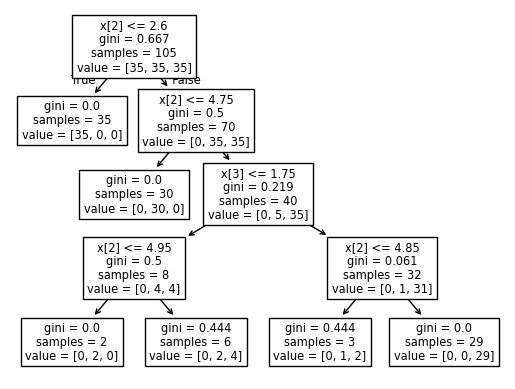

In [4]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(criterion='gini', 
                                    max_depth=4,
                                    splitter="best",
                                    random_state=42)
tree_model.fit(X_train, y_train)
print("特徵重要程度:",tree_model.feature_importances_)
from sklearn import tree

tree.plot_tree(tree_model)

In [5]:
y_pred=tree_model.predict(X_test)
accuracy=1-(y_test != y_pred).sum()/len(y_test)
print(f'accuracy: %d ' % (accuracy*100))
from sklearn.metrics import accuracy_score
print('accuracy: %.3f' % accuracy_score(y_test, y_pred))

accuracy: 97 
accuracy: 0.978


In [6]:
y_pred=tree_model.predict(X_train)
accuracy=1-(y_train != y_pred).sum()/len(y_train)
print(f'accuracy: %d ' % (accuracy*100))

accuracy: 97 


In [7]:
from itertools import combinations
import pandas as pd
from anytree import Node, RenderTree
class DecisionTree_C():
    def __init__(self, *,max_depth):
        self.tree_node=None         # 根節點
        self.max_depth_=max_depth   # 最多樹狀層次
        self.depth_count_ = 0       # 目前樹狀層次
        self.feature_importances=np.zeros(4)    # 特徵重要度
    class Tree_node():
        def __init__(self,node_type="root",feature=None,threshold=None,
                     is_leaf=False,left_child=None,right_child=None,
                     impurity=1,value=[]):
            self.node_type = node_type
            self.feature = feature
            self.is_leaf = is_leaf
            self.threshold = threshold
            self.left_child = left_child
            self.right_child = right_child
            self.impurity = impurity
            self.value = value
            self.prediction = None

        def _prediction(self,sample:np.ndarray):
            # 如果是葉節點
            if self.is_leaf:
                z=np.where(self.value >0) # tree_node.prediction  # 返回多數類或平均值
                return z
            else:
                # 否则是内部節點
                feature_value = sample[self.feature]  # 樣本該節點的特徵值
                threshold = self.threshold 
                # 根据判断走向左或右子節點
                if feature_value <= threshold:
                   return self.left_child._prediction(sample)
                else:
                   return self.right_child._prediction(sample)
        def plot(self):
            def break_down(treeNode,node:Node=None):
                name = f"gini = {treeNode.impurity}\nsamples = {sum(treeNode.value)}\nvalue = {treeNode.value}"
                if ((treeNode.left_child is not None) or (treeNode.right_child is not None)):
                    name = f"X[{treeNode.feature}]<={treeNode.threshold}\n"+name
                
                child = Node(name=name, parent=node) 
                if (treeNode.left_child is not None):
                    break_down(treeNode.left_child,child)
                if (treeNode.right_child is not None):
                    break_down(treeNode.right_child,child)
                
            root = Node(name=f"X[{self.feature}]<={self.threshold}\ngini = {self.impurity}\nsamples = {sum(self.value)}\nvalue = {self.value}")
            if (self.left_child is not None):
                break_down(self.left_child,root)
            if (self.right_child is not None):
                break_down(self.right_child,root)
            for pre, fill, node in RenderTree(root):
                # 將name分割成多行
                lines = node.name.split('\n')
                
                # 'pre' 是第一行
                print(f"{pre}{lines[0]}")
                
                # 'fill' 是其它行
                for line in lines[1:]:
                    print(f"{fill}{line}")         
        def __str__(self):  # print 物件專用
            return (f"'featrure':{self.feature},'threshold':{self.threshold},"
            f"'impurity':{self.impurity},'is_leaf':{self.impurity==0},'samples':{sum(self.value)},"
            f"'value':{self.value}")
        
    def _check_overlap(self,start1, end1, start2, end2):  # 判斷 類別1與2之間的feature是否有重疊
        return not (end1 < start2 or end2 < start1)        
    def fit(self,X,y):
        self.size_=len(np.unique(y))    # 類別數
        dataset=np.hstack((X,y.reshape(y.shape[0],1)))    # 對齊X、y給予合併
        root_node_impurity=self._gini_impurity(dataset)  
        self.tree_node=self.Tree_node(impurity=root_node_impurity,is_leaf=(root_node_impurity==0),
                                      value=np.bincount(y))
        self._break_down(dataset,self.tree_node,self.depth_count_)
        self.feature_importances=self.feature_importances/sum(self.feature_importances)
        self.is_fitted_ = True
        return self.tree_node
    def _candidate_threshold(self,dataset:np.ndarray,feature)->list : # 可能的分割點        
        res=set()   
        ds=dataset[:,(feature,-1)]  # 取dataset中特徵值、類別值
        ind = np.lexsort((ds[:, 1], ds[:, 0]))  # 索引指標依特徵值+類別排序
        data=ds[ind]            # 排序後資料集
        for c in combinations(np.unique(dataset[:,-1]),2):
            cd= data[:,-1]==c[0]    # 設條件
            start_idx_0 = np.argmin(data[cd][:,0])  #  符合條件的起始指標
            min0=data[cd][:,0][start_idx_0]         #  符合條件的最小值
            end_idx_0 = np.argmax(data[cd][:,0])    #  符合條件的截止指標
            max0=data[cd][:,0][end_idx_0]           #  符合條件的最大值

            cd= data[:,-1]==c[1]    # 設條件
            start_idx_1 = np.argmin(data[cd][:,0])  #  符合條件的起始指標
            min1=data[cd][:,0][start_idx_1]         #  符合條件的最小值
            end_idx_1 = np.argmax(data[cd][:,0])    #  符合條件的截止指標
            max1=data[cd][:,0][end_idx_1]           #  符合條件的最大值
                    
            if not (self._check_overlap(min0,max0,min1,max1)):    # feature沒有重疊
                x=(min1+max0)/2 if min1>max0 else (min0+max1)/2     # 取兩個feature間的中間值為可能值
                res.add(x)
            else :
                start = min(min0,min1)
                end = max(max0,max1)
                cd = (data[:,0]>=start)  &  (data[:,0]<=end)
                dt = data[cd] 
                for row in dt:
                     cd1 = (dt[:,-1]!=row[-1]) & (dt[:,0] < row[0])
                     if (dt[cd1].size !=0):
                        tmpdt=dt[cd1]
                        pr = dt[np.argmax(tmpdt[:,0])]
                        res.add((pr[0]+row[0])/2)
        return list(res)
    def _gini_split(self,dataset:np.ndarray,threshold,feature)->dict: # 左右Gini 不純度
        result={}
        subset=dataset[dataset[:,feature]<=threshold]
        result['left']=self._gini_impurity(subset)
        subset=dataset[dataset[:,feature]>threshold]
        result['right']=self._gini_impurity(subset)
        return result
    def _weighted_gini(self,dataset:np.ndarray,threshold,feature):    # 加權後的 Gini (分割指標)，期望值
        splited_gini=self._gini_split(dataset,threshold,feature)
        N_p = dataset.shape[0]   # 子集分割前樣本數
        N_l = dataset[dataset[:,feature]<=threshold].shape[0]    # 分割後左節點樣本數
        N_r = dataset[dataset[:,feature]>threshold].shape[0]     # 分割後右節點樣本數
        I_l = splited_gini["left"]       # 左節點不純度
        I_r = splited_gini["right"]      # 右節點不純度
        return N_l/N_p*I_l + N_r/N_p*I_r
        
    def _gini_impurity(self,subset:np.ndarray):     # 計算節點(node)的Gini 不純度(impurity)
        I=1
        for c in np.unique(subset[:,-1]):    # 1-各類別比例的平方
            I-=(subset[subset[:,-1]==c].shape[0]/subset.shape[0])**2
        return I
    def _break_down(self,dataset,parent_node:Tree_node,depth_count):
        if parent_node.is_leaf or depth_count >= self.max_depth_:
            return
        impurity = 1        
        # for f in reversed(range(dataset.shape[1]-1)):  # 對每一個feature處理
        for f in range(dataset.shape[1]-1):  # 對每一個feature處理
            splitters=self._candidate_threshold(dataset=dataset,feature=f)    # 候選分割點
            
            for splitter in splitters:     # 可能的閾值
                weighted=self._weighted_gini(     # 計算閾值區分左右子集後之權重gini不純度
                    dataset,
                    threshold=splitter,
                    feature=f)    
                if (weighted<impurity):   # 尋求最小gini 不純度
                    impurity=weighted
                    parent_node.feature=f
                    parent_node.threshold=splitter
        # print(f"parent node-->{node}")
        self.feature_importances[parent_node.feature] += parent_node.impurity-impurity      
        left_subset=dataset[dataset[:,parent_node.feature]<=parent_node.threshold]        
        left_impurity=self._gini_impurity(left_subset)
        parent_node.left_child=self.Tree_node(impurity=left_impurity,is_leaf=(left_impurity==0),
                                       value=np.bincount(left_subset[:,-1].reshape(-1).astype(np.int64),minlength=self.size_))
        # print(f"left node-->{node.left_child}")
        right_subset=dataset[dataset[:,parent_node.feature]>parent_node.threshold]
        right_impurity=self._gini_impurity(right_subset)
        parent_node.right_child=self.Tree_node(impurity=right_impurity,is_leaf=(right_impurity==0),
                                        value=np.bincount(right_subset[:,-1].reshape(-1).astype(np.int64),minlength=self.size_))   
        # print(f"right node-->{node.right_child}")
        depth_count +=1
        if (not parent_node.right_child.is_leaf):
            self._break_down(right_subset,parent_node.right_child,depth_count)
        if (not parent_node.left_child.is_leaf):
            self._break_down(left_subset,parent_node.left_child,depth_count)
    
    def predict(self,tree_node:Tree_node, samples)->np.ndarray:
        result = np.array([])
        for sample in samples:
            label = tree_node._prediction(sample)
            result = np.append(result,label)
        return result
            

In [8]:
dtc=DecisionTree_C(max_depth=4)
rootnode=dtc.fit(X_train,y_train)
print("特徵重要程度:",dtc.feature_importances)
rootnode.plot()

特徵重要程度: [0.        0.        0.9270763 0.0729237]
X[2]<=2.5999999999999996
gini = 0.6666666666666665
samples = 105
value = [35 35 35]
├── gini = 0.0
│   samples = 35
│   value = [35  0  0]
└── X[2]<=4.75
    gini = 0.5
    samples = 70
    value = [ 0 35 35]
    ├── gini = 0.0
    │   samples = 30
    │   value = [ 0 30  0]
    └── X[3]<=1.7
        gini = 0.21875
        samples = 40
        value = [ 0  5 35]
        ├── X[2]<=4.95
        │   gini = 0.5
        │   samples = 8
        │   value = [0 4 4]
        │   ├── gini = 0.0
        │   │   samples = 2
        │   │   value = [0 2 0]
        │   └── gini = 0.4444444444444444
        │       samples = 6
        │       value = [0 2 4]
        └── X[2]<=4.85
            gini = 0.060546875
            samples = 32
            value = [ 0  1 31]
            ├── gini = 0.4444444444444444
            │   samples = 3
            │   value = [0 1 2]
            └── gini = 0.0
                samples = 29
                value = [ 0  0

In [9]:
y_pred=dtc.predict(dtc.tree_node,X_test)
accuracy=1-(y_test != y_pred).sum()/len(y_test)
print(f'accuracy: %d ' % (accuracy*100))
print('accuracy: %.3f' % accuracy_score(y_test, y_pred))

accuracy: 97 
accuracy: 0.978


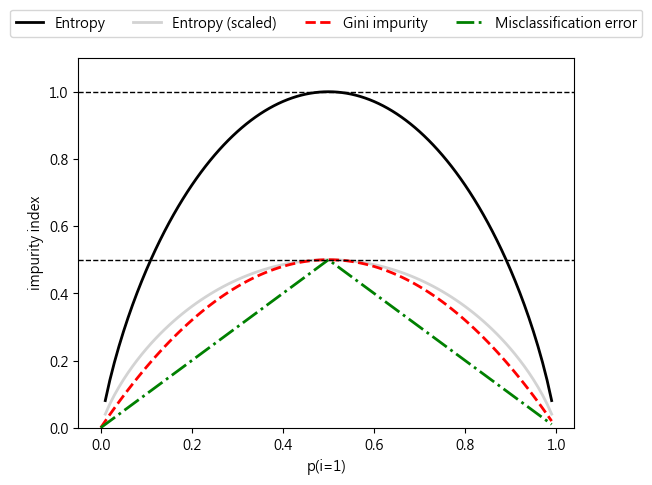

In [10]:
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']  # 用於正常顯示中文標籤
plt.rcParams['axes.unicode_minus'] = False  # 用於正常顯示負號(若有負數資料)
def gini(p):    # 基尼不純度
    return p * (1 - p) + (1 - p) * (1 - (1 - p))

def entropy(p): # 熵不純度
    return - p * np.log2(p) - (1 - p) * np.log2((1 - p))

def error(p):   # 分類誤差
    return 1 - np.max([p, 1 - p])

x = np.arange(0.0, 1.0, 0.01)

ent = [entropy(p) if p != 0 else None for p in x]
sc_ent = [e * 0.5 if e else None for e in ent]
err = [error(i) for i in x]

fig = plt.figure()
ax = plt.subplot(111)
for i, lab, ls, c, in zip([ent, sc_ent, gini(x), err], 
                          ['Entropy', 'Entropy (scaled)', 
                           'Gini impurity', 'Misclassification error'],
                          ['-', '-', '--', '-.'],
                          ['black', 'lightgray', 'red', 'green', 'cyan']):
    line = ax.plot(x, i, label=lab, linestyle=ls, lw=2, color=c)

ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15),
          ncol=5, fancybox=True, shadow=False)

ax.axhline(y=0.5, linewidth=1, color='k', linestyle='--')
ax.axhline(y=1.0, linewidth=1, color='k', linestyle='--')
plt.ylim([0, 1.1])
plt.xlabel('p(i=1)')
plt.ylabel('impurity index')
plt.show()

# 隨機森林(Random Forest)-- 分類器

In [11]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

# iris的資料105筆比較決策樹與隨機森林

In [12]:
from sklearn.metrics import accuracy_score, classification_report
y_pred_dt = tree_model.predict(X_test)
y_pred_rf = rf.predict(X_test)
print("=== 決策樹 ===")
print(f"準確率: {accuracy_score(y_test, y_pred_dt):.4f}")
print("分類報告:")
print(classification_report(y_test, y_pred_dt))

print("\n=== 隨機森林 ===")
print(f"準確率: {accuracy_score(y_test, y_pred_rf):.4f}")
print("分類報告:")
print(classification_report(y_test, y_pred_rf))

=== 決策樹 ===
準確率: 0.9778
分類報告:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.94      1.00      0.97        15
           2       1.00      0.93      0.97        15

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45


=== 隨機森林 ===
準確率: 0.9778
分類報告:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.94      1.00      0.97        15
           2       1.00      0.93      0.97        15

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



# 產生一個有 1000 筆資料、5 個特徵的分類問題，其中只有 2 個特徵真正有用，其餘是雜訊

In [13]:
np.random.seed(42)

# 產生 1000 筆資料
n_samples = 1000
# 有用特徵：基於兩個維度產生類別標籤
X1 = np.random.randn(n_samples)
X2 = np.random.randn(n_samples)
# 類別標籤 (複雜非線性邊界)
y = ((X1**2 + X2**2 + 0.2 * np.random.randn(n_samples)) > 1.2).astype(int)

# 加上 3 個無關的雜訊特徵 (純高斯雜訊)
X3 = np.random.randn(n_samples)
X4 = np.random.randn(n_samples)
X5 = np.random.randn(n_samples)

# 合併特徵矩陣
X = np.column_stack([X1, X2, X3, X4, X5])
feature_names = ['X1', 'X2', 'X3', 'X4', 'X5']

# 分割訓練集與測試集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [14]:
# 決策樹 (無修剪，允許長到最大深度)
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# 隨機森林 (100 棵樹，其他參數預設)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# 預測
y_pred_dt = dt.predict(X_test)
y_pred_rf = rf.predict(X_test)


In [15]:
print("=== 決策樹 ===")
print(f"準確率: {accuracy_score(y_test, y_pred_dt):.4f}")
print("分類報告:")
print(classification_report(y_test, y_pred_dt))

print("\n=== 隨機森林 ===")
print(f"準確率: {accuracy_score(y_test, y_pred_rf):.4f}")
print("分類報告:")
print(classification_report(y_test, y_pred_rf))

=== 決策樹 ===
準確率: 0.8833
分類報告:
              precision    recall  f1-score   support

           0       0.89      0.86      0.87       138
           1       0.88      0.91      0.89       162

    accuracy                           0.88       300
   macro avg       0.88      0.88      0.88       300
weighted avg       0.88      0.88      0.88       300


=== 隨機森林 ===
準確率: 0.9100
分類報告:
              precision    recall  f1-score   support

           0       0.92      0.88      0.90       138
           1       0.90      0.93      0.92       162

    accuracy                           0.91       300
   macro avg       0.91      0.91      0.91       300
weighted avg       0.91      0.91      0.91       300



# 特徵重要性分析 (隨機森林的強項)

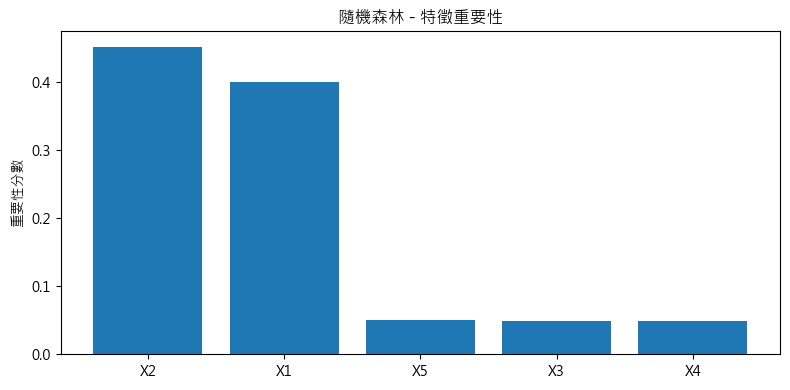

X2: 0.4522
X1: 0.4008
X5: 0.0498
X3: 0.0486
X4: 0.0486


In [16]:
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

# 繪製長條圖
plt.figure(figsize=(8,4))
plt.title("隨機森林 - 特徵重要性")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), [feature_names[i] for i in indices])
plt.ylabel("重要性分數")
plt.tight_layout()
plt.show()

# 輸出排序後的重要性
for i in indices:
    print(f"{feature_names[i]}: {importances[i]:.4f}")